In [113]:
import sys
!{sys.executable} -m pip install --upgrade pyLDAvis

In [114]:
import pyLDAvis
print(pyLDAvis.__version__)
print(dir(pyLDAvis))

3.4.0
['PreparedData', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_display', '_prepare', '_server', 'disable_notebook', 'display', 'enable_notebook', 'gensim_models', 'js_PCoA', 'lda_model', 'prepare', 'prepared_data_to_html', 'save_html', 'save_json', 'show', 'urls', 'utils']


In [115]:
import sys
!{sys.executable} -m pip install pyLDAvis==3.4.1

In [116]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nltk
import spacy
from bs4 import BeautifulSoup
import contractions


# Gensim (LDA)
import scipy
import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim import matutils


# Sklearn (LSA, NMF, TF-IDF)
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import LatentDirichletAllocation


# Visualization
from wordcloud import WordCloud
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
import pyLDAvis.lda_model as ldavis_model

# NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords

import pickle

# spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

print('✅ All imports successful')

✅ All imports successful


In [117]:
#Retrieve the dataset without having to import the dataset again

%store -r disneyland_df

In [118]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords,tokenized_texts,cleaned_texts
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,if you have ever been to disneyland anywhere y...,ever anywhere find similar layout walk main st...,"[ever, anywhere, find, similar, layout, walk, ...",ever anywhere find similar layout walk main st...
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,its been a while since d last time we visit hk...,since last visit hk yet stay tomorrowland aka ...,"[since, last, visit, yet, stay, tomorrowland, ...",since last visit yet stay tomorrowland aka mar...
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,thanks god it wasn t too hot or too humid when...,thanks god hot humid visiting otherwise big is...,"[thank, god, hot, humid, visit, otherwise, big...",thank god hot humid visit otherwise big issue ...
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,hk disneyland is a great compact park unfortu...,hk great compact unfortunately bit maintenance...,"[great, compact, unfortunately, bit, maintenan...",great compact unfortunately bit maintenance wo...
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,the location is not in the city took around ...,location city around hour kowlon kids everythi...,"[location, city, around, hour, kowlon, kid, ev...",location city around hour kowlon kid everythin...
...,...,...,...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,i went to disneyland paris in july and thou...,july thought brilliant visited hotels stayed n...,"[july, brilliant, visit, hotel, stay, newport,...",july brilliant visit hotel stay newport bay ky...
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,adults and child of visited disneyland ...,adults child visited beginning feb absolute fa...,"[adult, child, visit, begin, feb, absolute, fa...",adult child visit begin feb absolute fantastic...
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,my eleven year old daughter and myself went to...,eleven year old daughter visit son london deci...,"[eleven, year, old, daughter, visit, son, lond...",eleven year old daughter visit son london deci...
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,this hotel part of the disneyland paris compl...,hotel part complex wonderful place families si...,"[hotel, part, complex, wonderful, place, famil...",hotel part complex wonderful place family sinc...


In [119]:
#Break Down the Different Categories
california_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_California']
hong_kong_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_HongKong']
paris_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_Paris']

# California LDA Code

This section of the code will use the LDA method of analysis to come up with the topics for the Disneyland reviews for Disneyland Anahiem (California). 

In [121]:
#Reset the index so there is no issue with indexing as the reviews are separated
california_reviews=california_reviews.reset_index(drop=True)

In [122]:
#Store the tokenized text in a variable
tokenized_texts_california=california_reviews['tokenized_texts']

In [123]:
california_reviews

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords,tokenized_texts,cleaned_texts
0,670801367,5,2019-4,United States,This place has always been and forever will be...,Disneyland_California,this place has always been and forever will be...,place always forever special feeling entering ...,"[place, always, forever, special, feeling, ent...",place always forever special feeling enter cha...
1,670760708,5,2019-4,United States,A great day of simple fun and thrills. Bring c...,Disneyland_California,a great day of simple fun and thrills bring c...,great simple fun thrills bring cash nothing ch...,"[great, simple, fun, thrill, bring, cash, noth...",great simple fun thrill bring cash nothing che...
2,670565072,4,2019-5,Australia,All and all a great day was had. The crowds ar...,Disneyland_California,all and all a great day was had the crowds ar...,great crowds huge ride times sometimes min wai...,"[great, crowd, huge, ride, sometimes, min, wai...",great crowd huge ride sometimes min wait worth...
3,670544335,5,2019-4,United States,Having been to the Florida location numerous t...,Disneyland_California,having been to the florida location numerous t...,location numerous times years compare smaller ...,"[location, numerous, year, compare, small, foo...",location numerous year compare small footprint...
4,670472278,5,2019-4,Canada,"Had the 4 day pass, spent 3 at DL and one at C...",Disneyland_California,had the day pass spent at dl and one at c...,pass spent dl ca great place visit saw days mi...,"[pass, spend, great, place, visit, miss, want]",pass spend great place visit miss want
...,...,...,...,...,...,...,...,...,...,...
19281,1563280,5,missing,United States,I have taken my music groups to Disneyland for...,Disneyland_California,i have taken my music groups to disneyland for...,taken music groups number years participate ma...,"[music, group, number, year, participate, magi...",music group number year participate magic musi...
19282,1540854,5,missing,United States,This is definitely the Happiest Place on Earth...,Disneyland_California,this is definitely the happiest place on earth...,happiest place earth long drives parks rides b...,"[happy, place, earth, long, drive, rid, well, ...",happy place earth long drive rid well fastpass...
19283,1534364,1,missing,United States,"never again...what a horrible experience, the ...",Disneyland_California,never again what a horrible experience the ...,never horrible experience worst weekend life u...,"[never, horrible, experience, bad, weekend, li...",never horrible experience bad weekend life und...
19284,1506324,5,missing,United States,We take a long weekend trip to California each...,Disneyland_California,we take a long weekend trip to california each...,long weekend trip january always start vacatio...,"[long, weekend, trip, january, always, start, ...",long weekend trip january always start vacatio...


In [124]:
# Gensim Dictionary: maps each unique token to an integer ID
california_dictionary = Dictionary(tokenized_texts_california)

# Filter extremes: remove tokens that appear in <5 docs or >80% of docs
california_dictionary.filter_extremes(no_below=5, no_above=0.80)
print(california_dictionary[0])

age


In [125]:
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer
#Create a set of the stopwords in english
STOP_WORDS = set(stopwords.words('english'))

# Add domain-specific stopwords that add noise
custom_stopwords = ['disneyland','disney','park','day','time','went','also','really','just','paris','hong','kong','anaheim',
                    'california','los','angeles','france','china','tokyo', 'orlando', 'florida','usa', 'one','two','get','got','make',
                    'made','back','even','still','us', 'like','would','could','should','much','many','lot','lots', 'thing', 'etc', 'french',
                    'chinese','english','things','something','anything','say','said','see','seen','know','think', 'go','going','come','came',
                    'take','took','almost','basically','certainly','completely','definitely','entirely','fully','literally','maybe',
                    'perhaps','probably','quite','really','somewhat','totally','very','actually','anyway','basically','essentially',
                    'generally','somehow','somewhat','though','usually','seem','feel','felt','appears','looks','starts','begins','that',
                    'this','there','down','up']

#We chose the first set of words because they are specific domain specific words that can drive the overall topic in a very specific direction and 
#and does not provide a general topic that can be applied to these reviews. Things like the location are very specific rather than topics like rides, food,
#etc. that can be applied to every single location in Disney. Other words that we decided to add to this list are very common words or words that add 
#emphasis because they do not bring anything else to the topic and can create noise depending on how many times these words show up in the reviews. 

#Combine the custom stop words and the standard stopwords into one list
STOP_WORDS = set(STOP_WORDS).union(custom_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [126]:
#Initialize the CountVectorizer method utilizing the combined list of stop words
california_count_vectorizer = CountVectorizer(
    stop_words=list(STOP_WORDS)) # Pass as a list or set)

#Apply the vectorizer to the cleaned reviews
california_count_matrix = california_count_vectorizer.fit_transform(california_reviews['cleaned_texts'])

print(california_count_vectorizer)

CountVectorizer(stop_words=['his', "i'll", 'won', "he'd", 'much', 'doing',
                            'french', 'where', 'wouldn', 'angeles', 'then',
                            'which', 'her', 'i', 'very', 'don', 'hers', 'maybe',
                            'perhaps', 'out', "she's", 'know', "i've", 'also',
                            'orlando', 'herself', "needn't", "shouldn't",
                            'said', 'until', ...])


In [127]:
#Retrieve the list of features produced by the vectorizer and generate the size of the vocabulary
print(f'Vocabulary size: {len(california_count_vectorizer.get_feature_names_out()):,} unique tokens')
#Use the count vectorizer matrix and show the size of the corup
print(f'Corpus size:     {california_count_matrix.shape[0]:,} documents')
print()
print('Example — first document (dense vector):')
print(california_count_matrix.toarray()[0])
print()
#Generate the words that we get from the applied method
california_feature_names = california_count_vectorizer.get_feature_names_out()
# Create (word, count) pairs for non-zero entries in first document
decoded = [(california_feature_names[col], california_count_matrix[0, col]) for col in california_count_matrix[0].indices]
print('Decoded:')
print(decoded)

Vocabulary size: 18,221 unique tokens
Corpus size:     19,286 documents

Example — first document (dense vector):
[0 0 0 ... 0 0 0]

Decoded:
[('place', 1), ('always', 1), ('forever', 1), ('special', 1), ('feeling', 1), ('enter', 1), ('character', 1), ('different', 1), ('attraction', 1), ('priceless', 1), ('dream', 1), ('trip', 1), ('age', 1), ('especially', 1), ('young', 1), ('kid', 1), ('spend', 1), ('money', 1), ('regret', 1)]


In [128]:

#Number of Topics to be tested
K_RANGE = [5, 8, 10, 12, 15]
california_coherence_scores = []
california_perplexity_scores = []

for k in K_RANGE:
    #Initialize the Model
    california_lda_model = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=50)
    # You must fit the model to your matrix produced by Count Vectorizer
    california_lda_model.fit(california_count_matrix) 

    # Get top word indices for each topic and reverse the argsort order to get highest probability words
    topic_indices = [matutils.argsort(topic, topn=20, reverse=True) for topic in california_lda_model.components_]
    
    # Convert indices to actual tokens since we using 'texts' for coherence calculation
    topics_as_tokens = [[california_feature_names[idx] for idx in topic] for topic in topic_indices]

    # Calculate Coherence using the 'topics' parameter
    cm = CoherenceModel(
        topics=topics_as_tokens,  # Use the extracted topics
        texts=tokenized_texts_california, 
        dictionary=california_dictionary, 
        coherence='c_v'
    )
    california_coherence_scores.append(cm.get_coherence())

    # Perplexity Calculations
    california_perplexity_scores.append(california_lda_model.perplexity(california_count_matrix))

# Print the results as needed
print("California Coherence Scores:", california_coherence_scores)
print("California Perplexity Scores:", california_perplexity_scores)


California Coherence Scores: [0.43585504220635796, 0.4270832380689373, 0.45278456485392793, 0.4318960983875228, 0.46723302136729516]
California Perplexity Scores: [1209.9514646904117, 1243.4566752062874, 1255.8327223292104, 1264.872036876449, 1268.180776320953]


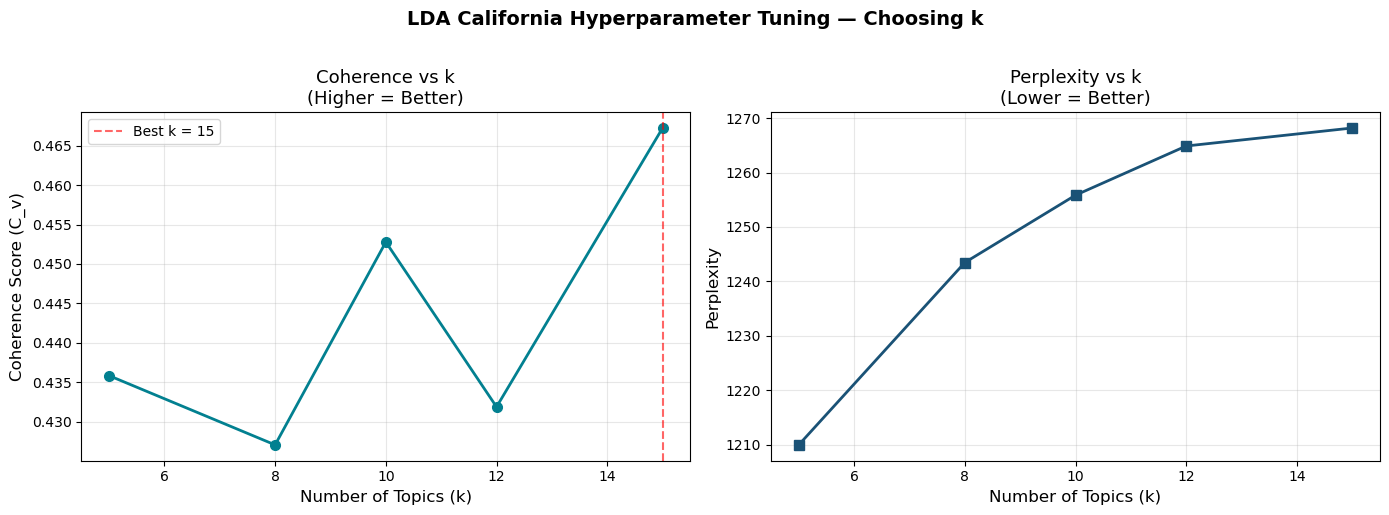

Best k by coherence: 15
Max coherence score: 0.4672


In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coherence
ax1.plot(list(K_RANGE), california_coherence_scores, 'o-', color='#028090', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Topics (k)', fontsize=12)
ax1.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax1.set_title('Coherence vs k\n(Higher = Better)', fontsize=13)
ax1.axvline(x=K_RANGE[california_coherence_scores.index(max(california_coherence_scores))],
            color='red', linestyle='--', alpha=0.6,
            label=f'Best k = {K_RANGE[california_coherence_scores.index(max(california_coherence_scores))]}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity
ax2.plot(list(K_RANGE), california_perplexity_scores, 's-', color='#1A5276', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Topics (k)', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs k\n(Lower = Better)', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA California Hyperparameter Tuning — Choosing k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("LDA_hyperparameter_tuning_california.png")
plt.show()

best_k = K_RANGE[california_coherence_scores.index(max(california_coherence_scores))]
print(f'Best k by coherence: {best_k}')
print(f'Max coherence score: {max(california_coherence_scores):.4f}')

In [130]:
NUM_TOPICS = K_RANGE[california_coherence_scores.index(max(california_coherence_scores))]  # Change this based on elbow chart
#Initialize the Model with the Optimal Number of Topics
california_lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42, max_iter=50)
print(f'✅ LDA model trained with k={NUM_TOPICS}')

california_lda_model.fit(california_count_matrix)

✅ LDA model trained with k=15


LatentDirichletAllocation(max_iter=50, n_components=15, random_state=42)

In [131]:
print("=== LDA Topic-Word Distributions ===\n")

for i, topic in enumerate(california_lda_model.components_):
    # Produces a list of indexes for words from most to least important
    top_indices = topic.argsort()[-20:][::-1]
    # Store the words and probability
    words = [(california_feature_names[idx], topic[idx]) for idx in top_indices]
    # Print and Join the words for the final list
    word_str = " | ".join([f"{w} ({p:.3f})" for w, p in words])
    print(f"Topic {i+1}: {word_str}")
    print()

=== LDA Topic-Word Distributions ===

Topic 1: staff (1433.064) | member (1429.527) | cast (1312.798) | friendly (1152.309) | clean (1004.116) | always (741.747) | helpful (738.541) | every (504.921) | service (450.984) | amazing (449.109) | experience (444.994) | great (426.782) | visit (377.730) | detail (354.574) | well (344.912) | magical (324.628) | employee (294.841) | happy (292.901) | help (280.666) | smile (277.045)

Topic 2: line (4928.168) | ride (3349.600) | wait (3140.086) | long (2221.991) | hour (1844.661) | people (1698.777) | crowd (1662.966) | minute (1632.911) | rid (1474.445) | break (931.501) | close (850.132) | walk (775.720) | way (662.188) | stroller (659.474) | around (638.100) | stand (502.957) | parking (480.696) | spend (480.045) | price (477.378) | visit (448.992)

Topic 3: show (3127.352) | firework (3123.599) | parade (3092.849) | night (1614.597) | watch (909.842) | light (828.505) | street (785.227) | main (764.052) | fantasmic (744.663) | good (629.136

In [132]:
# ── Evaluate final model ─────────────────────────────────────────
topic_indices = [matutils.argsort(topic, topn=20, reverse=True) for topic in california_lda_model.components_]
    
    # Convert indices to actual tokens since we are using 'texts' for coherence calculation
topics_as_tokens = [[california_feature_names[idx] for idx in topic] for topic in topic_indices]

    # Calculate Coherence 
cm_final = CoherenceModel(
        topics=topics_as_tokens,  # Use the extracted topics
        texts=tokenized_texts_california, 
        dictionary=california_dictionary, 
        coherence='c_v'
    )
california_coherence_final = cm_final.get_coherence()
california_perplexity_final = california_lda_model.perplexity(california_count_matrix)

print(f'Final Coherence (C_v): {california_coherence_final:.4f}  (higher = better)')
print(f'Final Perplexity:      {california_perplexity_final:.2f}  (lower  = better)')

Final Coherence (C_v): 0.4672  (higher = better)
Final Perplexity:      1268.18  (lower  = better)


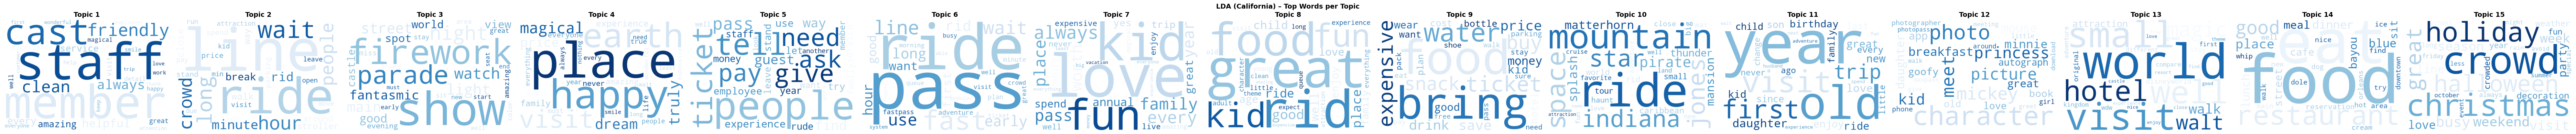

In [133]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))

california_lda_topic_words = {}
feature_names = california_count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(california_lda_model.components_):
    top_indices = topic.argsort()[-30:][::-1]
    word_weights = {california_feature_names[idx]: topic[idx] for idx in top_indices}

    california_lda_topic_words[f"Topic {topic_idx}"] = list(word_weights.keys())[:10]

    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='Blues'
    ).generate_from_frequencies(word_weights)

    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx+1}', fontsize=14, fontweight='bold')

plt.suptitle('LDA (California) – Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("word_cloud_comparison_california.png")
plt.show()

In [134]:
def get_doc_topic_df(model, doc_term_matrix, n_topics):
    """Return a DataFrame of topic probabilities per document."""
    doc_topic_matrix = model.transform(doc_term_matrix)
    return pd.DataFrame(
        doc_topic_matrix,
        columns=[f"Topic_{i+1}" for i in range(n_topics)]
    )

doc_topic_df = get_doc_topic_df(california_lda_model, california_count_matrix, NUM_TOPICS)
doc_topic_df.head(8).round(3)

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,Topic_11,Topic_12,Topic_13,Topic_14,Topic_15
0,0.003,0.003,0.003,0.422,0.003,0.003,0.248,0.289,0.003,0.003,0.003,0.003,0.003,0.003,0.003
1,0.002,0.201,0.002,0.002,0.002,0.002,0.002,0.170,0.559,0.002,0.002,0.048,0.002,0.002,0.002
2,0.002,0.332,0.097,0.075,0.002,0.471,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002
3,0.001,0.001,0.001,0.001,0.001,0.354,0.001,0.001,0.001,0.304,0.056,0.001,0.274,0.001,0.001
4,0.008,0.008,0.008,0.274,0.008,0.618,0.008,0.008,0.008,0.008,0.008,0.008,0.008,0.008,0.008
5,0.148,0.007,0.007,0.471,0.007,0.007,0.302,0.007,0.007,0.007,0.007,0.007,0.007,0.007,0.007
6,0.090,0.002,0.166,0.002,0.194,0.213,0.002,0.002,0.092,0.002,0.002,0.230,0.002,0.002,0.002
7,0.002,0.387,0.002,0.036,0.002,0.355,0.002,0.002,0.002,0.053,0.148,0.002,0.002,0.002,0.002


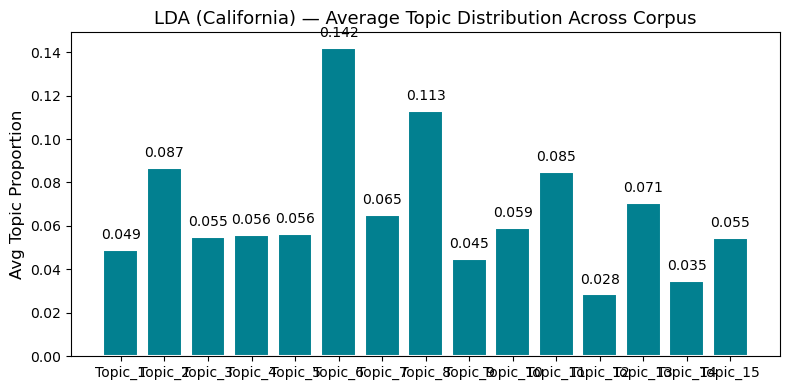

In [135]:
# Average topic proportion across corpus
avg = doc_topic_df.mean()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(avg.index, avg.values, color='#028090', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Topic Proportion', fontsize=12)
ax.set_title('LDA (California) — Average Topic Distribution Across Corpus', fontsize=13)
for bar, val in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("lda_california_avg_topic_distribution.png")
plt.show()

In [136]:
# What is the dominant topic for each document?
doc_topic_df['dominant_topic'] = doc_topic_df.iloc[:, :NUM_TOPICS].idxmax(axis=1)

# Sample: show a few docs and their dominant topic
sample = doc_topic_df.copy()
sample['text_preview'] = [d[:250] + '...' for d in disneyland_df['cleaned_texts'][:len(sample)]]

topic_array=sample['dominant_topic'].value_counts()
topic_list=topic_array.index.to_list()

# Produce the output with topic probability score and sample
for i in topic_list:
    current_sample=sample[sample['dominant_topic'] == i]
    print(f'10 Documents with the Highest Topic Probability for {i}')
    print(current_sample[['dominant_topic', i, 'text_preview']].sort_values(by=i, ascending=False).head(10).to_string(),'\n')



sample['dominant_topic']
print(f'\nTopic distribution across documents:')
print(doc_topic_df['dominant_topic'].value_counts())

10 Documents with the Highest Topic Probability for Topic_6
      dominant_topic   Topic_6                                                                                                                                                                                                                                                   text_preview
11481        Topic_6  0.982390                      celebrate special need aunt birthday amazing enjoy morning closing fantastic show spectacular highly recommend firework cancel night due wind disappoint close adventure cast member amazing aunt spoil birthday lifetime never forget...
9343         Topic_6  0.976667  trip second trip trip trip plan world several month birthday mum love branding experience however trip worth hour travel way walk main street specifically ask good restaurant western food direct corner cafe zoo table separate mere noise chaos distrac...
15772        Topic_6  0.976068                                                    

In [137]:
# ── pyLDAvis — run in Jupyter for interactive chart ──────────────
# Left panel:  circles = topics; size = prevalence; spacing = distinctiveness
# Right panel: word bars for selected topic
# λ slider:    0 = most unique words; 1 = most frequent; try λ = 0.6
import pyLDAvis
import pyLDAvis.lda_model as ldavis_model

#Initialize the notebook environment
pyLDAvis.enable_notebook()

# Produce the Visual
california_lda_vis = ldavis_model.prepare(
    california_lda_model,
    california_count_matrix,
    california_count_vectorizer,
    sort_topics=False
)
pyLDAvis.save_html(california_lda_vis, 'california_lda_visualization.html')
pyLDAvis.display(california_lda_vis)


In [138]:
# After inspecting pyLDAvis and word clouds, assign human-readable names
# ADJUST THESE based on your actual output words
TOPIC_NAMES = {
    'Topic 0': 'Space & Astronomy',
    'Topic 1': 'Baseball & Sports',
    'Topic 2': 'Gun Politics & Rights',
    'Topic 3': 'Computer Graphics & Tech',
}
print('Topic Names:')
for k, v in TOPIC_NAMES.items():
    top_words = ', '.join(california_lda_topic_words[k][:6])
    print(f'  {k} → {v:30s}  ({top_words})')

Topic Names:
  Topic 0 → Space & Astronomy               (staff, member, cast, friendly, clean, always)
  Topic 1 → Baseball & Sports               (line, ride, wait, long, hour, people)
  Topic 2 → Gun Politics & Rights           (show, firework, parade, night, watch, light)
  Topic 3 → Computer Graphics & Tech        (place, happy, earth, visit, magical, truly)


# Paris LDA Code

This section of the code will use the LDA method of analysis to come up with the topics for the Disneyland reviews for Disneyland Paris. 

In [140]:
#Reset the index so there is no issue with indexing as the reviews are separated
paris_reviews=paris_reviews.reset_index(drop=True)

In [141]:
#Store the tokenized text in a variable
tokenized_texts_paris=paris_reviews['tokenized_texts']

In [142]:
# Gensim Dictionary: maps each unique token to an integer ID
paris_dictionary = Dictionary(tokenized_texts_paris)

# Filter extremes: remove tokens that appear in <5 docs or >80% of docs
paris_dictionary.filter_extremes(no_below=5, no_above=0.80)
print(paris_dictionary[0])

amount


In [143]:
#Initialize the CountVectorizer method utilizing the combined list of stop words. Not rewriting the list of stopwords
paris_count_vectorizer = CountVectorizer(
    stop_words=list(STOP_WORDS)) # Pass as a list or set)

#Apply the vectorizer to the cleaned reviews
paris_count_matrix = paris_count_vectorizer.fit_transform(paris_reviews['cleaned_texts'])

print(paris_count_vectorizer)

CountVectorizer(stop_words=['his', "i'll", 'won', "he'd", 'much', 'doing',
                            'french', 'where', 'wouldn', 'angeles', 'then',
                            'which', 'her', 'i', 'very', 'don', 'hers', 'maybe',
                            'perhaps', 'out', "she's", 'know', "i've", 'also',
                            'orlando', 'herself', "needn't", "shouldn't",
                            'said', 'until', ...])


In [144]:
#Retrieve the list of features produced by the vectorizer and generate the size of the vocabulary
print(f'Vocabulary size: {len(paris_count_vectorizer.get_feature_names_out()):,} unique tokens')
#Use the count vectorizer matrix and show the size of the corup
print(f'Corpus size:     {paris_count_matrix.shape[0]:,} documents')
print()
print('Example — first document (dense vector):')
print(paris_count_matrix.toarray()[0])
print()
#Generate the words that we get from the applied method
paris_feature_names = paris_count_vectorizer.get_feature_names_out()
# Create (word, count) pairs for non-zero entries in first document
decoded = [(paris_feature_names[col], paris_count_matrix[0, col]) for col in paris_count_matrix[0].indices]
print('Decoded:')
print(decoded)

Vocabulary size: 21,161 unique tokens
Corpus size:     13,598 documents

Example — first document (dense vector):
[0 0 0 ... 0 0 0]

Decoded:
[('hongkong', 1), ('far', 1), ('well', 1), ('look', 1), ('forward', 1), ('visit', 2), ('big', 1), ('enough', 1), ('recommend', 1), ('stay', 1), ('hotel', 1), ('resort', 1), ('enjoy', 1), ('fast', 2), ('track', 2), ('save', 1), ('huge', 1), ('amount', 1), ('staying', 1), ('plan', 1), ('strategize', 1), ('pass', 1), ('kiosk', 1), ('nearby', 1), ('attraction', 1), ('ride', 1), ('projection', 1), ('firework', 1), ('show', 1), ('world', 1)]


In [ ]:

#Number of Topics
K_RANGE = [5, 8, 10, 12, 15]
paris_coherence_scores = []
paris_perplexity_scores = []

for k in K_RANGE:
    #Initialize the Model
    paris_lda_model = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=50)
    # You must fit the model to your matrix produced by Count Vectorizer
    paris_lda_model.fit(paris_count_matrix) 

    # Get top word indices for each topic and reverse the argsort order to get highest probability words
    topic_indices = [matutils.argsort(topic, topn=20, reverse=True) for topic in paris_lda_model.components_]
    
    # Convert indices to actual tokens since we using 'texts' for coherence calculation
    topics_as_tokens = [[paris_feature_names[idx] for idx in topic] for topic in topic_indices]

    # Calculate Coherence using the 'topics' parameter
    cm = CoherenceModel(
        topics=topics_as_tokens,  # Use the extracted topics
        texts=tokenized_texts_paris, 
        dictionary=paris_dictionary, 
        coherence='c_v'
    )
    paris_coherence_scores.append(cm.get_coherence())

    # Perplexity Calculations
    paris_perplexity_scores.append(paris_lda_model.perplexity(paris_count_matrix))

# Print the results as needed
print("Paris Coherence Scores:", paris_coherence_scores)
print("Paris Perplexity Scores:", paris_perplexity_scores)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coherence
ax1.plot(list(K_RANGE), paris_coherence_scores, 'o-', color='#028090', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Topics (k)', fontsize=12)
ax1.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax1.set_title('Coherence vs k\n(Higher = Better)', fontsize=13)
ax1.axvline(x=K_RANGE[paris_coherence_scores.index(max(paris_coherence_scores))],
            color='red', linestyle='--', alpha=0.6,
            label=f'Best k = {K_RANGE[paris_coherence_scores.index(max(paris_coherence_scores))]}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity
ax2.plot(list(K_RANGE), paris_perplexity_scores, 's-', color='#1A5276', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Topics (k)', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs k\n(Lower = Better)', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Paris Hyperparameter Tuning — Choosing k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("LDA_hyperparameter_tuning_paris.png")
plt.show()

best_k = K_RANGE[paris_coherence_scores.index(max(paris_coherence_scores))]
print(f'Best k by coherence: {best_k}')
print(f'Max coherence score: {max(paris_coherence_scores):.4f}')

In [ ]:
NUM_TOPICS = K_RANGE[paris_coherence_scores.index(max(paris_coherence_scores))]  # Change this based on elbow chart
#Initialize the Model with the Optimal Number of Topics
paris_lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42, max_iter=50)
print(f'✅ LDA model trained with k={NUM_TOPICS}')

paris_lda_model.fit(paris_count_matrix)

In [ ]:
print("=== LDA Topic-Word Distributions ===\n")

for i, topic in enumerate(paris_lda_model.components_):
    # Produces a list of indexes for words from most to least important
    top_indices = topic.argsort()[-20:][::-1]
    # Store the words and probability
    words = [(paris_feature_names[idx], topic[idx]) for idx in top_indices]
    # Print and Join the words for the final list
    word_str = " | ".join([f"{w} ({p:.3f})" for w, p in words])
    print(f"Topic {i+1}: {word_str}")
    print()

In [ ]:
# ── Evaluate final model ─────────────────────────────────────────
topic_indices = [matutils.argsort(topic, topn=20, reverse=True) for topic in paris_lda_model.components_]
    
    # Convert indices to actual tokens since we are using 'texts' for coherence calculation
topics_as_tokens = [[paris_feature_names[idx] for idx in topic] for topic in topic_indices]

    # Calculate Coherence 
cm_final = CoherenceModel(
        topics=topics_as_tokens,  # Use the extracted topics
        texts=tokenized_texts_paris, 
        dictionary=paris_dictionary, 
        coherence='c_v'
    )
paris_coherence_final = cm_final.get_coherence()
paris_perplexity_final = paris_lda_model.perplexity(paris_count_matrix)

print(f'Final Coherence (C_v): {paris_coherence_final:.4f}  (higher = better)')
print(f'Final Perplexity:      {paris_perplexity_final:.2f}  (lower  = better)')

In [ ]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))

paris_lda_topic_words = {}
feature_names = paris_count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(paris_lda_model.components_):
    top_indices = topic.argsort()[-30:][::-1]
    word_weights = {paris_feature_names[idx]: topic[idx] for idx in top_indices}

    paris_lda_topic_words[f"Topic {topic_idx}"] = list(word_weights.keys())[:10]

    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='Blues'
    ).generate_from_frequencies(word_weights)

    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx+1}', fontsize=14, fontweight='bold')

plt.suptitle('LDA (Paris) – Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("word_cloud_comparison_paris.png")
plt.show()

In [ ]:
# Generate Topic Probability dataframe for each document
doc_topic_df = get_doc_topic_df(paris_lda_model, paris_count_matrix, NUM_TOPICS)
doc_topic_df.head(8).round(3)

In [ ]:
# Average topic proportion across corpus
avg = doc_topic_df.mean()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(avg.index, avg.values, color='#028090', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Topic Proportion', fontsize=12)
ax.set_title('LDA (Paris) — Average Topic Distribution Across Corpus', fontsize=13)
for bar, val in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("lda_paris_avg_topic_distribution.png")
plt.show()

In [ ]:
# What is the dominant topic for each document?
doc_topic_df['dominant_topic'] = doc_topic_df.iloc[:, :NUM_TOPICS].idxmax(axis=1)

# Sample: show a few docs and their dominant topic
sample = doc_topic_df.copy()
sample['text_preview'] = [d[:250] + '...' for d in disneyland_df['cleaned_texts'][:len(sample)]]

topic_array=sample['dominant_topic'].value_counts()
topic_list=topic_array.index.to_list()

# Produce the output with topic probability score and sample
for i in topic_list:
    current_sample=sample[sample['dominant_topic'] == i]
    print(f'10 Documents with the Highest Topic Probability for {i}')
    print(current_sample[['dominant_topic', i, 'text_preview']].sort_values(by=i, ascending=False).head(10).to_string(),'\n')



sample['dominant_topic']
print(f'\nTopic distribution across documents:')
print(doc_topic_df['dominant_topic'].value_counts())

In [ ]:
# ── pyLDAvis — run in Jupyter for interactive chart ──────────────
# Left panel:  circles = topics; size = prevalence; spacing = distinctiveness
# Right panel: word bars for selected topic
# λ slider:    0 = most unique words; 1 = most frequent; try λ = 0.6
import pyLDAvis
import pyLDAvis.lda_model as ldavis_model

#Initialize the notebook environment
pyLDAvis.enable_notebook()

# Produce the Visual
paris_lda_vis = ldavis_model.prepare(
    paris_lda_model,
    paris_count_matrix,
    paris_count_vectorizer,
    sort_topics=False
)
pyLDAvis.save_html(paris_lda_vis, 'paris_lda_visualization.html')
pyLDAvis.display(paris_lda_vis)

In [ ]:
# After inspecting pyLDAvis and word clouds, assign human-readable names
# ADJUST THESE based on your actual output words
TOPIC_NAMES = {
    'Topic 0': 'Space & Astronomy',
    'Topic 1': 'Baseball & Sports',
    'Topic 2': 'Gun Politics & Rights',
    'Topic 3': 'Computer Graphics & Tech',
}
print('Topic Names:')
for k, v in TOPIC_NAMES.items():
    top_words = ', '.join(paris_lda_topic_words[k][:6])
    print(f'  {k} → {v:30s}  ({top_words})')

# Hong Kong LDA Code

This section of the code will use the LDA method of analysis to come up with the topics for the Disneyland reviews for Disneyland Hong Kong. 

In [ ]:
#Reset the index so there is no issue with indexing as the reviews are separated
hong_kong_reviews=hong_kong_reviews.reset_index(drop=True)

In [ ]:
#Store the tokenized text in a variable
tokenized_texts_hong_kong=hong_kong_reviews['tokenized_texts']

In [ ]:
# Gensim Dictionary: maps each unique token to an integer ID
hong_kong_dictionary = Dictionary(tokenized_texts_hong_kong)

# Filter extremes: remove tokens that appear in <5 docs or >80% of docs
hong_kong_dictionary.filter_extremes(no_below=5, no_above=0.80)
print(hong_kong_dictionary[0])

In [ ]:
#Initialize the CountVectorizer method utilizing the combined list of stop words. Not rewriting the list of stopwords
hong_kong_count_vectorizer = CountVectorizer(
    stop_words=list(STOP_WORDS)) # Pass as a list or set)

#Apply the vectorizer to the cleaned reviews
hong_kong_count_matrix = hong_kong_count_vectorizer.fit_transform(hong_kong_reviews['cleaned_texts'])

print(hong_kong_count_vectorizer)

In [ ]:
#Retrieve the list of features produced by the vectorizer and generate the size of the vocabulary
print(f'Vocabulary size: {len(hong_kong_count_vectorizer.get_feature_names_out()):,} unique tokens')
#Use the count vectorizer matrix and show the size of the corup
print(f'Corpus size:     {hong_kong_count_matrix.shape[0]:,} documents')
print()
print('Example — first document (dense vector):')
print(hong_kong_count_matrix.toarray()[0])
print()
#Generate the words that we get from the applied method
hong_kong_feature_names = hong_kong_count_vectorizer.get_feature_names_out()
# Create (word, count) pairs for non-zero entries in first document
decoded = [(hong_kong_feature_names[col], hong_kong_count_matrix[0, col]) for col in hong_kong_count_matrix[0].indices]
print('Decoded:')
print(decoded)

In [ ]:

#Number of Topics
K_RANGE = [5, 8, 10, 12, 15]
hong_kong_coherence_scores = []
hong_kong_perplexity_scores = []

for k in K_RANGE:
    #Initialize the Model
    hong_kong_lda_model = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=50)
    # You must fit the model to your matrix produced by Count Vectorizer
    hong_kong_lda_model.fit(paris_count_matrix) 

    # Get top word indices for each topic and reverse the argsort order to get highest probability words
    topic_indices = [matutils.argsort(topic, topn=20, reverse=True) for topic in hong_kong_lda_model.components_]
    
    # Convert indices to actual tokens since we using 'texts' for coherence calculation
    topics_as_tokens = [[hong_kong_feature_names[idx] for idx in topic] for topic in topic_indices]

    # Calculate Coherence using the 'topics' parameter
    cm = CoherenceModel(
        topics=topics_as_tokens,  # Use the extracted topics
        texts=tokenized_texts_hong_kong, 
        dictionary=hong_kong_dictionary, 
        coherence='c_v'
    )
    hong_kong_coherence_scores.append(cm.get_coherence())

    # Perplexity Calculations
    hong_kong_perplexity_scores.append(hong_kong_lda_model.perplexity(hong_kong_count_matrix))

# Print the results as needed
print("Hong Kong Coherence Scores:", hong_kong_coherence_scores)
print("Hong Kong Perplexity Scores:", hong_kong_perplexity_scores)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coherence
ax1.plot(list(K_RANGE), hong_kong_coherence_scores, 'o-', color='#028090', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Topics (k)', fontsize=12)
ax1.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax1.set_title('Coherence vs k\n(Higher = Better)', fontsize=13)
ax1.axvline(x=K_RANGE[hong_kong_coherence_scores.index(max(hong_kong_coherence_scores))],
            color='red', linestyle='--', alpha=0.6,
            label=f'Best k = {K_RANGE[hong_kong_coherence_scores.index(max(hong_kong_coherence_scores))]}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity
ax2.plot(list(K_RANGE), hong_kong_perplexity_scores, 's-', color='#1A5276', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Topics (k)', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs k\n(Lower = Better)', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Hong Kong Hyperparameter Tuning — Choosing k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("LDA_hyperparameter_tuning_hong_kong.png")
plt.show()

best_k = K_RANGE[hong_kong_coherence_scores.index(max(hong_kong_coherence_scores))]
print(f'Best k by coherence: {best_k}')
print(f'Max coherence score: {max(hong_kong_coherence_scores):.4f}')

In [ ]:
NUM_TOPICS = K_RANGE[hong_kong_coherence_scores.index(max(hong_kong_coherence_scores))]  # Change this based on elbow chart
#Initialize the Model with the Optimal Number of Topics
hong_kong_lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42, max_iter=50)
print(f'✅ LDA model trained with k={NUM_TOPICS}')

hong_kong_lda_model.fit(hong_kong_count_matrix)

In [ ]:
print("=== LDA Topic-Word Distributions ===\n")

for i, topic in enumerate(hong_kong_lda_model.components_):
    # Produces a list of indexes for words from most to least important
    top_indices = topic.argsort()[-20:][::-1]
    # Store the words and probability
    words = [(hong_kong_feature_names[idx], topic[idx]) for idx in top_indices]
    # Print and Join the words for the final list
    word_str = " | ".join([f"{w} ({p:.3f})" for w, p in words])
    print(f"Topic {i+1}: {word_str}")
    print()

In [ ]:
# ── Evaluate final model ─────────────────────────────────────────
topic_indices = [matutils.argsort(topic, topn=20, reverse=True) for topic in hong_kong_lda_model.components_]
    
    # Convert indices to actual tokens since we are using 'texts' for coherence calculation
topics_as_tokens = [[hong_kong_feature_names[idx] for idx in topic] for topic in topic_indices]

    # Calculate Coherence 
cm_final = CoherenceModel(
        topics=topics_as_tokens,  # Use the extracted topics
        texts=tokenized_texts_hong_kong, 
        dictionary=hong_kong_dictionary, 
        coherence='c_v'
    )
hong_kong_coherence_final = cm_final.get_coherence()
hong_kong_perplexity_final = hong_kong_lda_model.perplexity(hong_kong_count_matrix)

print(f'Final Coherence (C_v): {hong_kong_coherence_final:.4f}  (higher = better)')
print(f'Final Perplexity:      {hong_kong_perplexity_final:.2f}  (lower  = better)')

In [ ]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))

hong_kong_lda_topic_words = {}
feature_names = hong_kong_count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(hong_kong_lda_model.components_):
    top_indices = topic.argsort()[-30:][::-1]
    word_weights = {hong_kong_feature_names[idx]: topic[idx] for idx in top_indices}

    hong_kong_lda_topic_words[f"Topic {topic_idx}"] = list(word_weights.keys())[:10]

    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='Blues'
    ).generate_from_frequencies(word_weights)

    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx+1}', fontsize=14, fontweight='bold')

plt.suptitle('LDA (Hong Kong) – Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("word_cloud_comparison_hong_kong.png")
plt.show()

In [ ]:
# Generate Topic Probability dataframe for each document
doc_topic_df = get_doc_topic_df(hong_kong_lda_model, hong_kong_count_matrix, NUM_TOPICS)
doc_topic_df.head(8).round(3)

In [ ]:
# Average topic proportion across corpus
avg = doc_topic_df.mean()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(avg.index, avg.values, color='#028090', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Topic Proportion', fontsize=12)
ax.set_title('LDA (Hong Kong) — Average Topic Distribution Across Corpus', fontsize=13)
for bar, val in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("lda_hong_kong_avg_topic_distribution.png")
plt.show()

In [ ]:
# What is the dominant topic for each document?
doc_topic_df['dominant_topic'] = doc_topic_df.iloc[:, :NUM_TOPICS].idxmax(axis=1)

# Sample: show a few docs and their dominant topic
sample = doc_topic_df.copy()
sample['text_preview'] = [d[:250] + '...' for d in disneyland_df['cleaned_texts'][:len(sample)]]

topic_array=sample['dominant_topic'].value_counts()
topic_list=topic_array.index.to_list()

# Produce the output with topic probability score and sample
for i in topic_list:
    current_sample=sample[sample['dominant_topic'] == i]
    print(f'10 Documents with the Highest Topic Probability for {i}')
    print(current_sample[['dominant_topic', i, 'text_preview']].sort_values(by=i, ascending=False).head(10).to_string(),'\n')



sample['dominant_topic']
print(f'\nTopic distribution across documents:')
print(doc_topic_df['dominant_topic'].value_counts())

In [ ]:
# ── pyLDAvis — run in Jupyter for interactive chart ──────────────
# Left panel:  circles = topics; size = prevalence; spacing = distinctiveness
# Right panel: word bars for selected topic
# λ slider:    0 = most unique words; 1 = most frequent; try λ = 0.6
import pyLDAvis
import pyLDAvis.lda_model as ldavis_model

#Initialize the notebook environment
pyLDAvis.enable_notebook()

# Produce the Visual
hong_kong_lda_vis = ldavis_model.prepare(
    hong_kong_lda_model,
    hong_kong_count_matrix,
    hong_kong_count_vectorizer,
    sort_topics=False
)
pyLDAvis.save_html(hong_kong_lda_vis, 'hong_kong_lda_visualization.html')
pyLDAvis.display(hong_kong_lda_vis)

In [ ]:
# After inspecting pyLDAvis and word clouds, assign human-readable names
# ADJUST THESE based on your actual output words
TOPIC_NAMES = {
    'Topic 0': 'Space & Astronomy',
    'Topic 1': 'Baseball & Sports',
    'Topic 2': 'Gun Politics & Rights',
    'Topic 3': 'Computer Graphics & Tech',
}
print('Topic Names:')
for k, v in TOPIC_NAMES.items():
    top_words = ', '.join(hong_kong_lda_topic_words[k][:6])
    print(f'  {k} → {v:30s}  ({top_words})')